In [2]:
import pandas as pd
import numpy as np

In [3]:
train='/kaggle/input/datasets/marquis03/flower-classification/train'
test='/kaggle/input/datasets/marquis03/flower-classification/val'

In [4]:
from tqdm import tqdm

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

2026-02-23 04:03:45.826095: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771819426.015189      80 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771819426.080617      80 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771819426.575588      80 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771819426.575630      80 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771819426.575632      80 computation_placer.cc:177] computation placer alr

In [6]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    train,
    image_size=(224,224),
    batch_size=32
)

Found 13642 files belonging to 14 classes.


I0000 00:00:1771819465.059320      80 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771819465.065142      80 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [7]:
class_names=train_ds.class_names

In [8]:
print(class_names)

['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


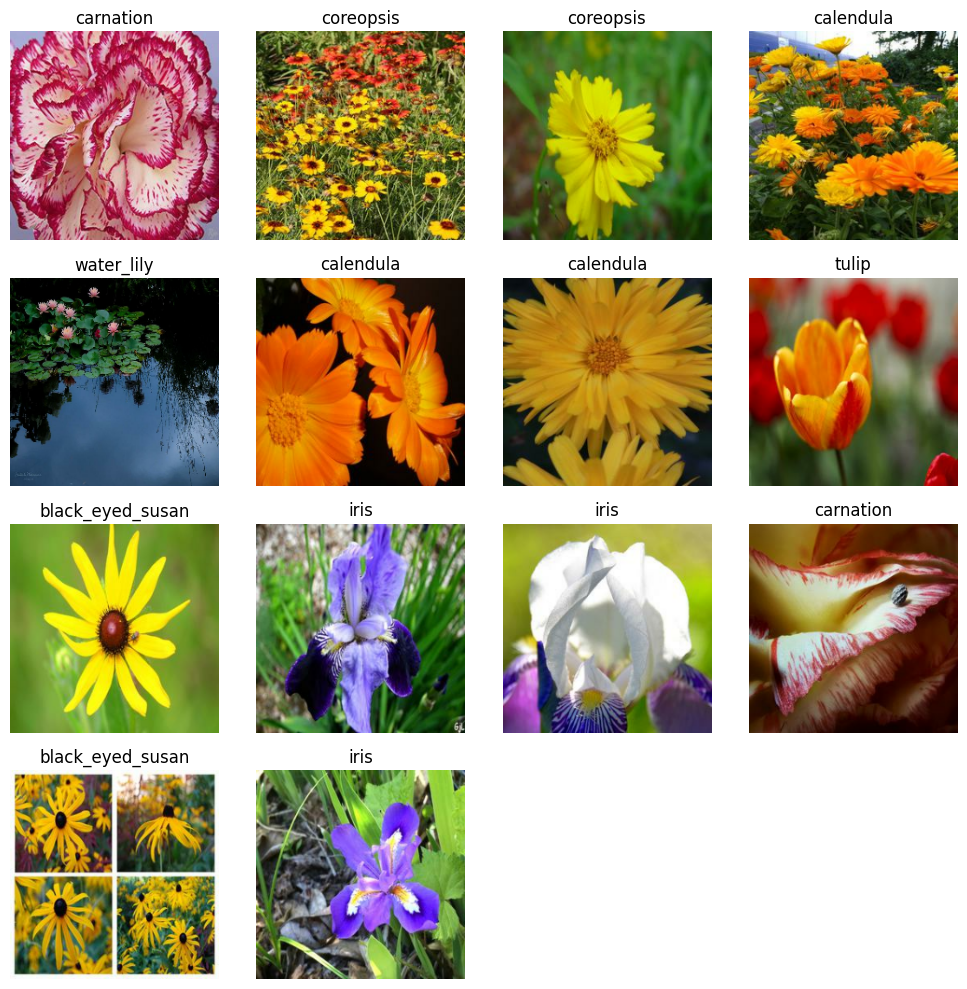

In [9]:
for images,labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(14):
        ax=plt.subplot(4,4,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()
        

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

In [11]:


def random_contrast(img):
    factor = tf.random.uniform([], 0.8, 1.2)
    img = tf.image.adjust_contrast(img, factor)
    return img

In [12]:
train_aug=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    # preprocessing_function=random_contrast,
    validation_split=0.2
                     
)

In [13]:
Image_size=(224,224)
batch_size=32
seed_value=123

In [14]:
train_generator=train_aug.flow_from_directory(
    train,
    target_size=Image_size,
    batch_size=batch_size,
    class_mode='categorical',
    seed=seed_value,
    subset='training'
)

Found 10919 images belonging to 14 classes.


In [15]:
val_generator=train_aug.flow_from_directory(
    train,
    target_size=Image_size,
    batch_size=batch_size,
    class_mode='categorical',
    seed=seed_value,
    subset='validation'
)

Found 2723 images belonging to 14 classes.


In [16]:
test_ds=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255.0
)

In [17]:
test_generator=test_ds.flow_from_directory(
    test,
    target_size=Image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
    
)

Found 98 images belonging to 14 classes.


In [18]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models, optimizers

In [19]:
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
num_classes=len(class_names)
print(num_classes)

14


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = 14

model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Flatten(),

    # Dense block
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
from tensorflow.keras.callbacks import EarlyStopping

In [23]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

In [24]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # if labels are integers
    metrics=['accuracy'],
    
)

#model.summary()

In [25]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[stop_early]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1771819477.376945     127 service.cc:152] XLA service 0x7d82040070f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771819477.376988     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771819477.376994     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771819478.000015     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/342 ━━━━━━━━━━━━━━━━━━━━ 30s 89ms/step - accuracy: 0.0859 - loss: 3.6459   

I0000 00:00:1771819485.964860     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 71/342 ━━━━━━━━━━━━━━━━━━━━ 2:17 508ms/step - accuracy: 0.1951 - loss: 2.7359

2026-02-23 04:05:23.251994: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 04:05:23.394948: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


342/342 ━━━━━━━━━━━━━━━━━━━━ 238s 663ms/step - accuracy: 0.2760 - loss: 2.2516 - val_accuracy: 0.2618 - val_loss: 2.1847
Epoch 2/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 155s 452ms/step - accuracy: 0.4150 - loss: 1.6659 - val_accuracy: 0.4102 - val_loss: 1.6797
Epoch 3/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 147s 431ms/step - accuracy: 0.4598 - loss: 1.5414 - val_accuracy: 0.5413 - val_loss: 1.3827
Epoch 4/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 149s 435ms/step - accuracy: 0.5152 - loss: 1.4089 - val_accuracy: 0.5053 - val_loss: 1.4574
Epoch 5/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 149s 435ms/step - accuracy: 0.5333 - loss: 1.3417 - val_accuracy: 0.5791 - val_loss: 1.2187
Epoch 6/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 149s 437ms/step - accuracy: 0.5638 - loss: 1.2652 - val_accuracy: 0.3573 - val_loss: 2.0495
Epoch 7/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 149s 434ms/step - accuracy: 0.5753 - loss: 1.2277 - val_accuracy: 0.6258 - val_loss: 1.1106
Epoch 8/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 150s 439ms/step - accuracy: 0.6011 - los

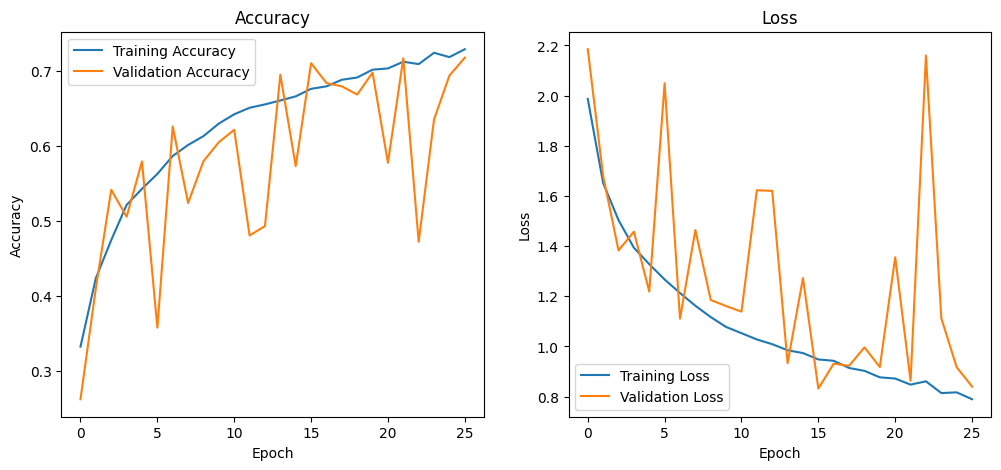

In [26]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [27]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 439ms/step - accuracy: 0.6112 - loss: 1.1337
Test Accuracy: 0.6530612111091614


In [28]:
base_model.trainable=False

In [29]:
model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(512, activation="relu"))
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation="softmax"))

In [31]:
model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

# Callback for early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Ensure that steps_per_epoch and validation_steps are correctly calculated
steps_per_epoch = train_generator.samples // batch_size
validation_steps = val_generator.samples // batch_size


In [33]:
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=50,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=[early_stopping]
)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 213s 548ms/step - accuracy: 0.4781 - loss: 5.5357 - val_accuracy: 0.8243 - val_loss: 0.5891
Epoch 2/50
  1/341 ━━━━━━━━━━━━━━━━━━━━ 32s 96ms/step - accuracy: 0.7188 - loss: 0.9680

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


341/341 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.7188 - loss: 0.9680 - val_accuracy: 0.8235 - val_loss: 0.5792
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 153s 449ms/step - accuracy: 0.6951 - loss: 0.9534 - val_accuracy: 0.8099 - val_loss: 0.6031
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 31s 90ms/step - accuracy: 0.7500 - loss: 0.8280 - val_accuracy: 0.8129 - val_loss: 0.6133
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 149s 438ms/step - accuracy: 0.7073 - loss: 0.8765 - val_accuracy: 0.8210 - val_loss: 0.5816
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 30s 89ms/step - accuracy: 0.5625 - loss: 1.0519 - val_accuracy: 0.8191 - val_loss: 0.5612
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 150s 439ms/step - accuracy: 0.7391 - loss: 0.8134 - val_accuracy: 0.8430 - val_loss: 0.4862
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 30s 88ms/step - accuracy: 0.6562 - loss: 1.1740 - val_accuracy: 0.8548 - val_loss: 0.4696
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 150s 440ms/step - accuracy: 0.7635 - loss: 0.7370 - val

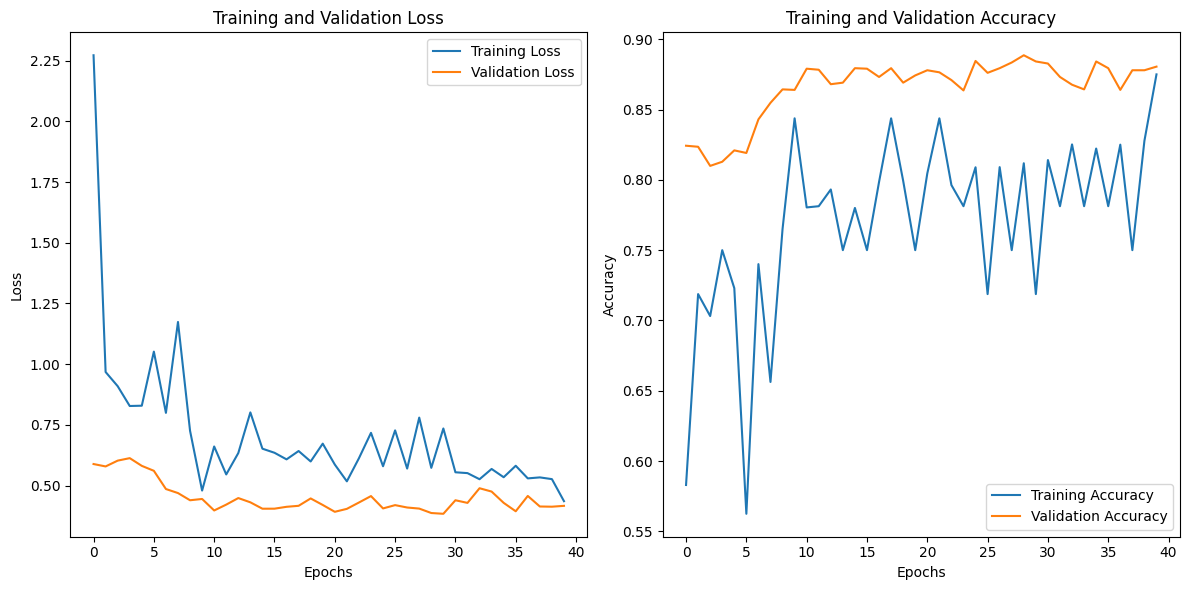

In [34]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
from sklearn.metrics import classification_report,confusion_matrix

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step 


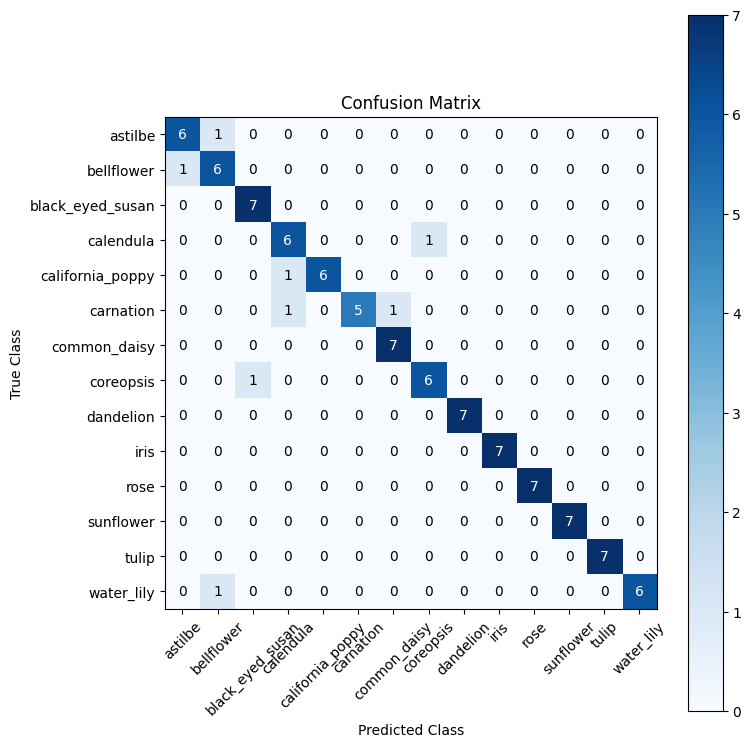

Classification Report:
                  precision    recall  f1-score   support

         astilbe       0.86      0.86      0.86         7
      bellflower       0.75      0.86      0.80         7
black_eyed_susan       0.88      1.00      0.93         7
       calendula       0.75      0.86      0.80         7
california_poppy       1.00      0.86      0.92         7
       carnation       1.00      0.71      0.83         7
    common_daisy       0.88      1.00      0.93         7
       coreopsis       0.86      0.86      0.86         7
       dandelion       1.00      1.00      1.00         7
            iris       1.00      1.00      1.00         7
            rose       1.00      1.00      1.00         7
       sunflower       1.00      1.00      1.00         7
           tulip       1.00      1.00      1.00         7
      water_lily       1.00      0.86      0.92         7

        accuracy                           0.92        98
       macro avg       0.93      0.92      0.92

In [37]:
y_true = test_generator.classes
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# Create the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 8))
plt.imshow(conf_matrix, cmap="Blues", interpolation="nearest")
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, test_generator.class_indices, rotation=45)
plt.yticks(tick_marks, test_generator.class_indices)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

# Annotate the cells with the values
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, str(conf_matrix[i, j]),
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")

plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices))